# Mercado Libre Delivery Promise Optimization Results Demo

This notebook presents the main artifacts generated by the prototype pipeline in a concise, reviewer-friendly format. It summarizes the proxy dataset, the point prediction baseline, and leaves clear placeholders for interval modeling and policy evaluation as later stages are produced.

All modeling and artifact generation should be run through the project scripts first. This notebook is intended only for result inspection and communication.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("bmh")
pd.options.display.float_format = "{:.4f}".format


def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError("Could not locate repository root from the current working directory.")


def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def render_note(text: str) -> None:
    display(Markdown(text))


def first_existing(paths: list[Path]) -> Path | None:
    for path in paths:
        if path.exists():
            return path
    return None


def find_column(columns, candidates) -> str | None:
    lowered = {column.lower(): column for column in columns}
    for candidate in candidates:
        if candidate.lower() in lowered:
            return lowered[candidate.lower()]
    return None


def flatten_metrics(metrics: dict) -> pd.DataFrame:
    rows = []
    for model_name, split_metrics in metrics.items():
        for split_name, values in split_metrics.items():
            rows.append(
                {
                    "model": model_name,
                    "split": split_name,
                    "MAE": values.get("mae"),
                    "RMSE": values.get("rmse"),
                    "R²": values.get("r2"),
                }
            )
    return pd.DataFrame(rows)


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "processed"
ARTIFACTS_DIR = REPO_ROOT / "artifacts"

print(f"Repository root: {REPO_ROOT}")


Repository root: /Users/andrestroiano/code/personal/mercado-envios-challenge


# 1. Dataset Overview


In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

dataset_summary = pd.DataFrame(
    {
        "rows": [len(train_df), len(val_df), len(test_df)],
        "columns": [train_df.shape[1], val_df.shape[1], test_df.shape[1]],
    },
    index=["train", "validation", "test"],
)

display(dataset_summary)

lead_time_all = pd.concat(
    [
        train_df[["lead_time_minutes", "seller_category"]],
        val_df[["lead_time_minutes", "seller_category"]],
        test_df[["lead_time_minutes", "seller_category"]],
    ],
    ignore_index=True,
)


,rows,columns
train,70000,23
validation,15000,23
test,15000,23


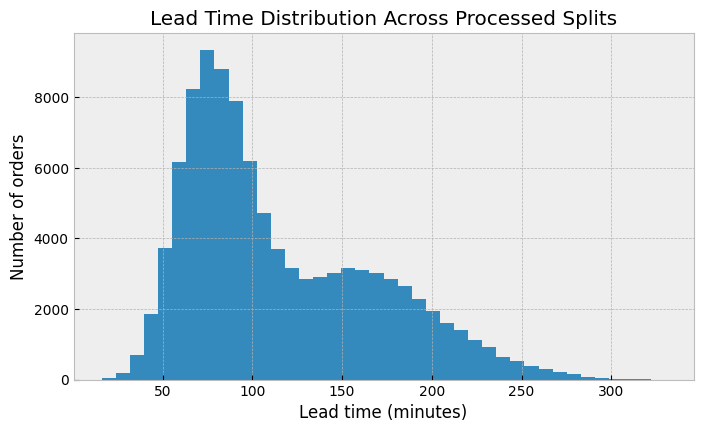

The proxy dataset shows a broad but plausible spread of lead times. It is not intended to perfectly reproduce marketplace logistics, but it provides a learnable and structured approximation of last-mile delivery dynamics.

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(lead_time_all["lead_time_minutes"], bins=40)
ax.set_title("Lead Time Distribution Across Processed Splits")
ax.set_xlabel("Lead time (minutes)")
ax.set_ylabel("Number of orders")
plt.show()

render_note(
    "The proxy dataset shows a broad but plausible spread of lead times. It is not intended to perfectly reproduce marketplace logistics, but it provides a learnable and structured approximation of last-mile delivery dynamics."
)


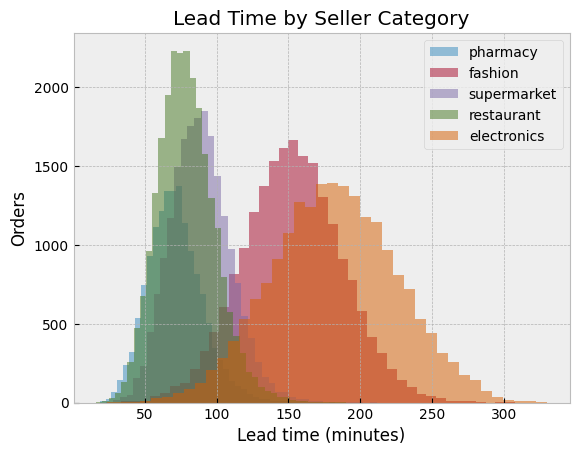

The lead-time distribution shows a bimodal structure. Categories such as restaurant, supermarket, and pharmacy cluster around shorter lead times with relatively concentrated distributions. In contrast, categories such as fashion and electronics exhibit longer and more variable lead times. This reflects heterogeneous operational dynamics across seller types, where differences in preparation complexity and handling requirements produce distinct delivery regimes.

In [4]:
for cat in lead_time_all["seller_category"].unique():
    subset = lead_time_all[lead_time_all["seller_category"] == cat]
    plt.hist(subset["lead_time_minutes"], bins=40, alpha=0.5, label=cat)

plt.legend()
plt.title("Lead Time by Seller Category")
plt.xlabel("Lead time (minutes)")
plt.ylabel("Orders")
plt.show()

render_note(
    "The lead-time distribution shows a bimodal structure. Categories such as restaurant, supermarket, and pharmacy cluster around shorter lead times with relatively concentrated distributions. In contrast, categories such as fashion and electronics exhibit longer and more variable lead times. This reflects heterogeneous operational dynamics across seller types, where differences in preparation complexity and handling requirements produce distinct delivery regimes."
)

# 2. Point Prediction Model


In [5]:
point_model_dir = ARTIFACTS_DIR / "point_model"
point_metrics = load_json(point_model_dir / "metrics.json")
point_metrics_df = flatten_metrics(point_metrics)
feature_importance_df = pd.read_csv(point_model_dir / "feature_importance.csv")
predictions_val_df = pd.read_csv(point_model_dir / "predictions_val.csv")
predictions_test_df = pd.read_csv(point_model_dir / "predictions_test.csv")

display(point_metrics_df)


,model,split,MAE,RMSE,R²
0,baseline,validation,44.1803,53.2213,-0.0007
1,baseline,test,44.3257,53.4853,-0.0008
2,lightgbm,validation,17.0481,24.9428,0.7802
3,lightgbm,test,16.7833,24.4578,0.7907


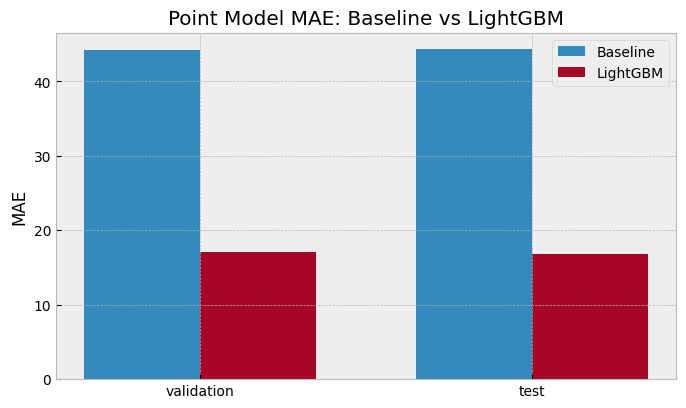

The LightGBM model materially improves on the mean-prediction baseline on both validation and test splits, which is a strong signal that the Stage 2 proxy dataset contains learnable structure.

In [6]:
metric_plot_df = pd.DataFrame(
    {
        "split": ["validation", "test"],
        "baseline": [
            point_metrics["baseline"]["validation"]["mae"],
            point_metrics["baseline"]["test"]["mae"],
        ],
        "LightGBM": [
            point_metrics["lightgbm"]["validation"]["mae"],
            point_metrics["lightgbm"]["test"]["mae"],
        ],
    }
)

x = np.arange(len(metric_plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, metric_plot_df["baseline"], width, label="Baseline")
ax.bar(x + width / 2, metric_plot_df["LightGBM"], width, label="LightGBM")
ax.set_xticks(x)
ax.set_xticklabels(metric_plot_df["split"])
ax.set_ylabel("MAE")
ax.set_title("Point Model MAE: Baseline vs LightGBM")
ax.legend()
plt.show()

render_note(
    "The LightGBM model materially improves on the mean-prediction baseline on both validation and test splits, which is a strong signal that the Stage 2 proxy dataset contains learnable structure."
)


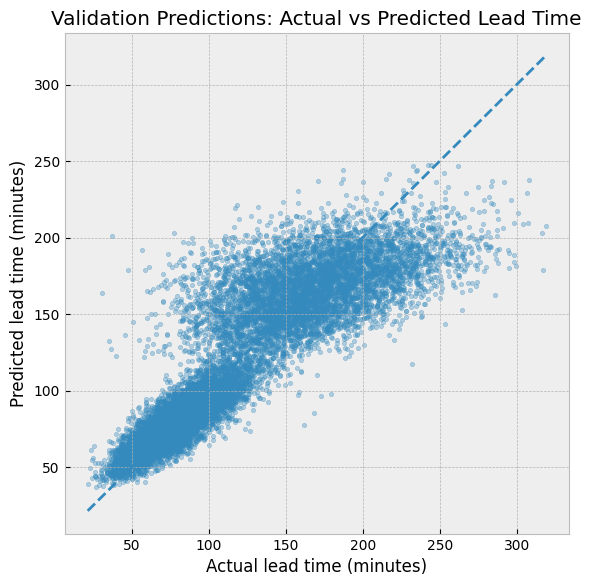

Predictions track the realized lead times reasonably well, especially through the middle of the distribution. The remaining spread indicates residual uncertainty that a point estimate alone cannot fully communicate.

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(
    predictions_val_df["actual_lead_time_minutes"],
    predictions_val_df["predicted_lead_time_minutes"],
    s=10,
    alpha=0.35,
)
axis_min = min(
    predictions_val_df["actual_lead_time_minutes"].min(),
    predictions_val_df["predicted_lead_time_minutes"].min(),
)
axis_max = max(
    predictions_val_df["actual_lead_time_minutes"].max(),
    predictions_val_df["predicted_lead_time_minutes"].max(),
)
ax.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--")
ax.set_title("Validation Predictions: Actual vs Predicted Lead Time")
ax.set_xlabel("Actual lead time (minutes)")
ax.set_ylabel("Predicted lead time (minutes)")
plt.show()

render_note(
    "Predictions track the realized lead times reasonably well, especially through the middle of the distribution. The remaining spread indicates residual uncertainty that a point estimate alone cannot fully communicate."
)


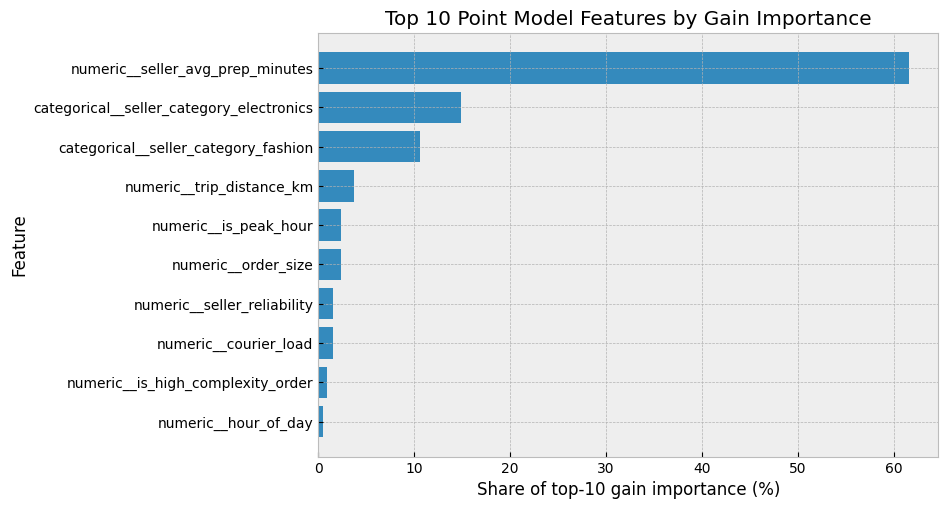

Operationally, the model is relying on four broad driver groups: seller preparation behavior, travel-related distance signals, congestion and temporal demand signals, and order complexity. That pattern is consistent with the intended problem framing: delivery lead time is shaped by both marketplace operations and transport dynamics.

In [8]:
top_features = feature_importance_df.sort_values("importance", ascending=False).head(10).copy()
top_features = top_features.iloc[::-1]
top_features["importance_pct"] = 100.0 * top_features["importance"] / top_features["importance"].sum()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top_features["feature_name"], top_features["importance_pct"])
ax.set_title("Top 10 Point Model Features by Gain Importance")
ax.set_xlabel("Share of top-10 gain importance (%)")
ax.set_ylabel("Feature")
plt.show()

render_note(
    "Operationally, the model is relying on four broad driver groups: seller preparation behavior, travel-related distance signals, congestion and temporal demand signals, and order complexity. That pattern is consistent with the intended problem framing: delivery lead time is shaped by both marketplace operations and transport dynamics."
)


# 3. Quantile Interval Model


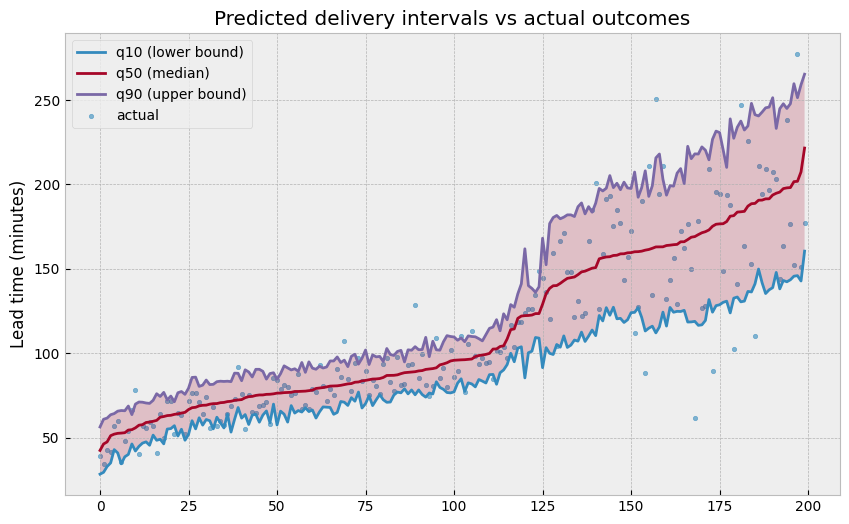

In [10]:
import matplotlib.pyplot as plt

interval_predictions_val = pd.read_csv(
    "../artifacts/quantile_model/interval_predictions_val.csv"
)

df = interval_predictions_val.sample(200).sort_values("pred_q50")

plt.figure(figsize=(10,6))

plt.plot(df["pred_q10"].values, label="q10 (lower bound)")
plt.plot(df["pred_q50"].values, label="q50 (median)")
plt.plot(df["pred_q90"].values, label="q90 (upper bound)")
plt.scatter(range(len(df)), df["actual_lead_time_minutes"], s=10, alpha=0.6, label="actual")

plt.fill_between(
    range(len(df)),
    df["pred_q10"],
    df["pred_q90"],
    alpha=0.2
)

plt.ylabel("Lead time (minutes)")
plt.title("Predicted delivery intervals vs actual outcomes")
plt.legend()

plt.show()

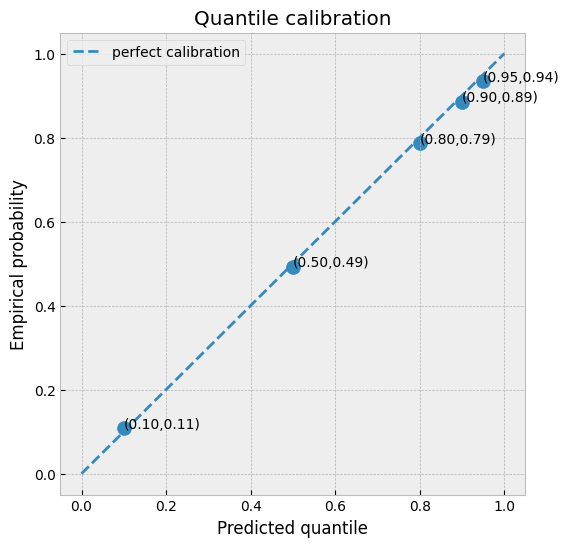

In [12]:
import numpy as np
import matplotlib.pyplot as plt

quantiles = [0.1, 0.5, 0.8, 0.9, 0.95]
empirical = [
    (interval_predictions_val["actual_lead_time_minutes"] <= interval_predictions_val["pred_q10"]).mean(),
    (interval_predictions_val["actual_lead_time_minutes"] <= interval_predictions_val["pred_q50"]).mean(),
    (interval_predictions_val["actual_lead_time_minutes"] <= interval_predictions_val["pred_q80"]).mean(),
    (interval_predictions_val["actual_lead_time_minutes"] <= interval_predictions_val["pred_q90"]).mean(),
    (interval_predictions_val["actual_lead_time_minutes"] <= interval_predictions_val["pred_q95"]).mean()
]

plt.figure(figsize=(6,6))

plt.plot([0,1],[0,1], linestyle="--", label="perfect calibration")

plt.scatter(quantiles, empirical, s=100)

for q,e in zip(quantiles, empirical):
    plt.text(q, e, f"({q:.2f},{e:.2f})")

plt.xlabel("Predicted quantile")
plt.ylabel("Empirical probability")

plt.title("Quantile calibration")
plt.legend()

plt.show()

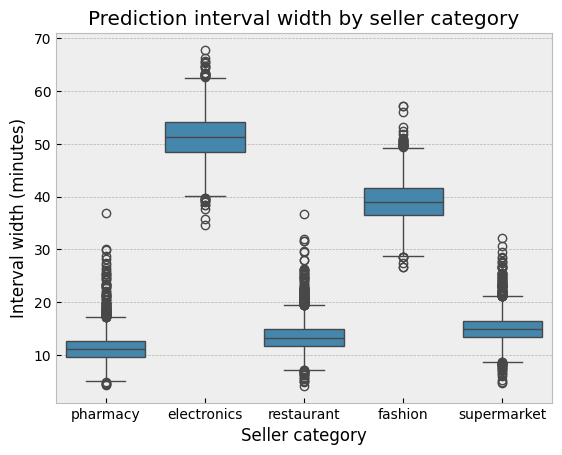

In [11]:
import seaborn as sns

sns.boxplot(
    x="seller_category",
    y="interval_width",
    data=interval_predictions_val
)

plt.title("Prediction interval width by seller category")
plt.ylabel("Interval width (minutes)")
plt.xlabel("Seller category")

plt.show()

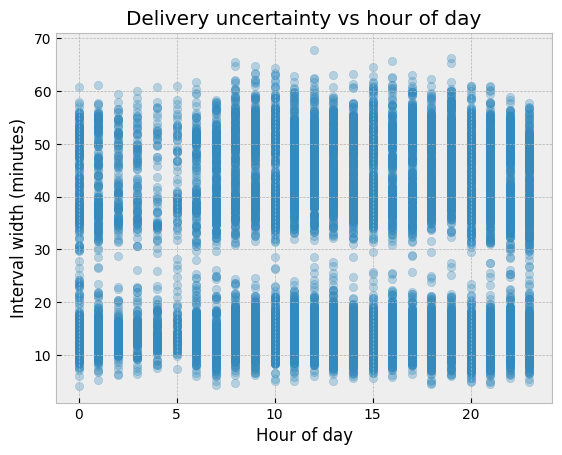

In [12]:
plt.scatter(
    interval_predictions_val["hour_of_day"],
    interval_predictions_val["interval_width"],
    alpha=0.3
)

plt.xlabel("Hour of day")
plt.ylabel("Interval width (minutes)")
plt.title("Delivery uncertainty vs hour of day")

plt.show()

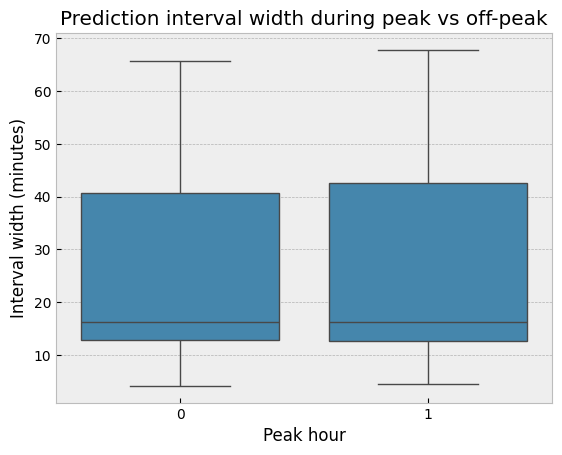

In [13]:
sns.boxplot(
    x="is_peak_hour",
    y="interval_width",
    data=interval_predictions_val
)

plt.xlabel("Peak hour")
plt.ylabel("Interval width (minutes)")
plt.title("Prediction interval width during peak vs off-peak")

plt.show()

In [18]:
q10_imp = pd.read_csv("../artifacts/quantile_model/feature_importance_q10.csv")
q50_imp = pd.read_csv("../artifacts/quantile_model/feature_importance_q50.csv")
q80_imp = pd.read_csv("../artifacts/quantile_model/feature_importance_q80.csv")
q90_imp = pd.read_csv("../artifacts/quantile_model/feature_importance_q90.csv")
q95_imp = pd.read_csv("../artifacts/quantile_model/feature_importance_q95.csv")

q10_imp["importance_norm"] = q10_imp["importance"] / q10_imp["importance"].sum()
q50_imp["importance_norm"] = q50_imp["importance"] / q50_imp["importance"].sum()
q80_imp["importance_norm"] = q80_imp["importance"] / q80_imp["importance"].sum()
q90_imp["importance_norm"] = q90_imp["importance"] / q90_imp["importance"].sum()
q95_imp["importance_norm"] = q95_imp["importance"] / q95_imp["importance"].sum()

top_q10 = q10_imp.sort_values("importance_norm", ascending=False).head(10)
top_q50 = q50_imp.sort_values("importance_norm", ascending=False).head(10)
top_q80 = q80_imp.sort_values("importance_norm", ascending=False).head(10)
top_q90 = q90_imp.sort_values("importance_norm", ascending=False).head(10)
top_q95 = q95_imp.sort_values("importance_norm", ascending=False).head(10)


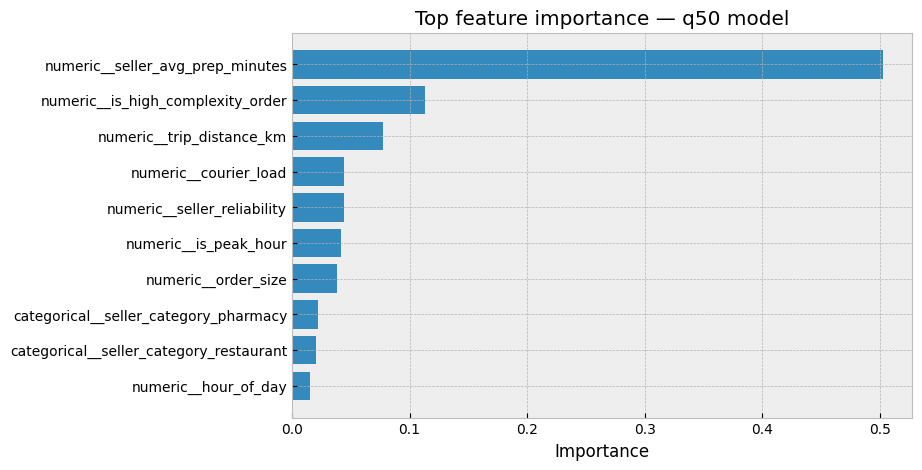

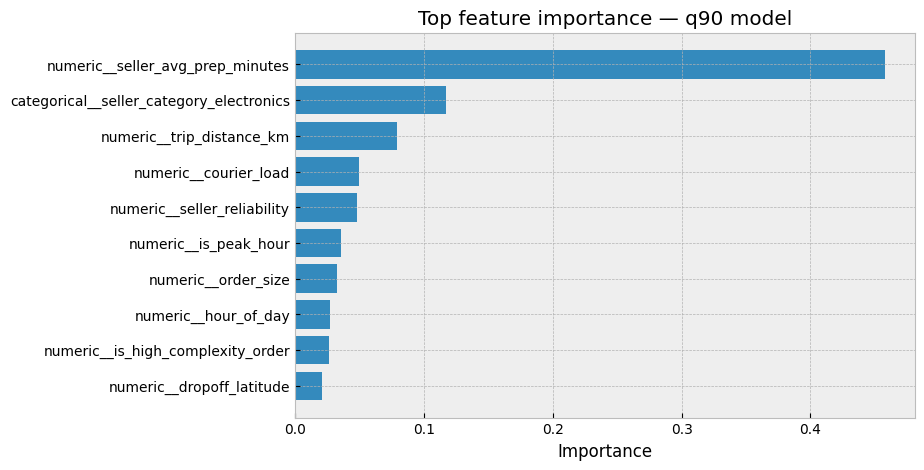

In [16]:
plt.figure(figsize=(8, 5))
plt.barh(top_q50["feature_name"][::-1], top_q50["importance_norm"][::-1])
plt.title("Top feature importance — q50 model")
plt.xlabel("Importance")
plt.show()

plt.figure(figsize=(8, 5))
plt.barh(top_q90["feature_name"][::-1], top_q90["importance_norm"][::-1])
plt.title("Top feature importance — q90 model")
plt.xlabel("Importance")
plt.show()

In [16]:
merged = q50_imp[["feature_name","importance_norm"]].merge(
    q90_imp[["feature_name","importance_norm"]],
    on="feature_name",
    suffixes=("_q50","_q90")
)

merged["importance_norm_q50"].corr(merged["importance_norm_q90"])

from scipy.stats import spearmanr

spearmanr(
    merged["importance_norm_q50"],
    merged["importance_norm_q90"]
)

SignificanceResult(statistic=np.float64(0.6610389610389611), pvalue=np.float64(0.0011040228328465568))

The Spearman correlation between feature importance rankings of the q50 and q90 models is 0.66, indicating that both models rely on broadly similar signals, while still exhibiting meaningful differences. This is expected because some variables primarily affect typical delivery times, whereas others influence the upper tail of the delivery time distribution.

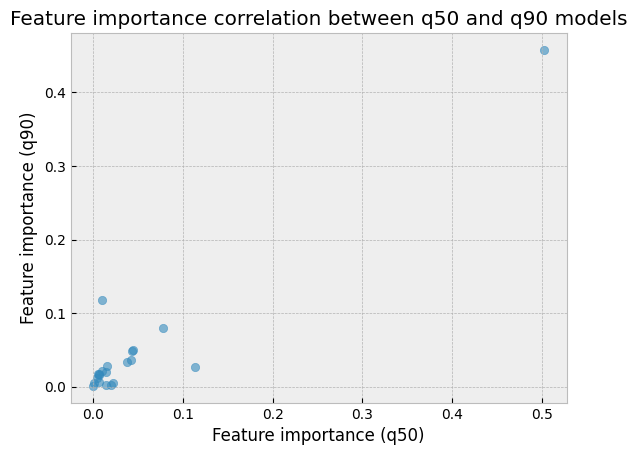

In [18]:
import matplotlib.pyplot as plt

plt.scatter(
    merged["importance_norm_q50"],
    merged["importance_norm_q90"],
    alpha=0.6
)

plt.xlabel("Feature importance (q50)")
plt.ylabel("Feature importance (q90)")
plt.title("Feature importance correlation between q50 and q90 models")

plt.show()

In [19]:
merged["rank_q50"] = merged["importance_norm_q50"].rank(ascending=False)
merged["rank_q90"] = merged["importance_norm_q90"].rank(ascending=False)

merged["rank_shift"] = merged["rank_q50"] - merged["rank_q90"]

merged.sort_values("rank_shift")

,feature_name,importance_norm_q50,importance_norm_q90,rank_q50,rank_q90,rank_shift
8,categorical__seller_category_restaurant,0.0203,0.0026,9.0000,19.0000,-10.0000
10,categorical__seller_category_supermarket,0.0145,0.0024,11.0000,20.0000,-9.0000
7,categorical__seller_category_pharmacy,0.0223,0.0055,8.0000,17.0000,-9.0000
1,numeric__is_high_complexity_order,0.1135,0.0268,2.0000,9.0000,-7.0000
15,numeric__priority_flag,0.0069,0.0057,16.0000,16.0000,0.0000
6,numeric__order_size,0.0378,0.0328,7.0000,7.0000,0.0000
0,numeric__seller_avg_prep_minutes,0.5025,0.4581,1.0000,1.0000,0.0000
4,numeric__seller_reliability,0.0438,0.0481,5.0000,5.0000,0.0000
3,numeric__courier_load,0.0444,0.0494,4.0000,4.0000,0.0000
2,numeric__trip_distance_km,0.0775,0.0793,3.0000,3.0000,0.0000


# 4. Policy Trade-off Analysis


,policy_name,lower_quantile,upper_quantile,avg_interval_width,late_delivery_rate,coverage,early_before_start_rate,avg_promise_start,avg_promise_end,n_rows_used,order_corrections,late_rate_rank,width_rank,pareto_efficient
0,conservative_q10_q95,0.1000,0.9500,59.0753,0.0694,0.8258,0.1048,89.0692,148.1445,15000,0,1,3,True
1,balanced_q10_q90,0.1000,0.9000,52.1267,0.1187,0.7765,0.1048,89.0692,141.1959,15000,0,2,2,True
2,aggressive_q10_q80,0.1000,0.8000,43.3297,0.2177,0.6775,0.1048,89.0692,132.3989,15000,0,3,1,True


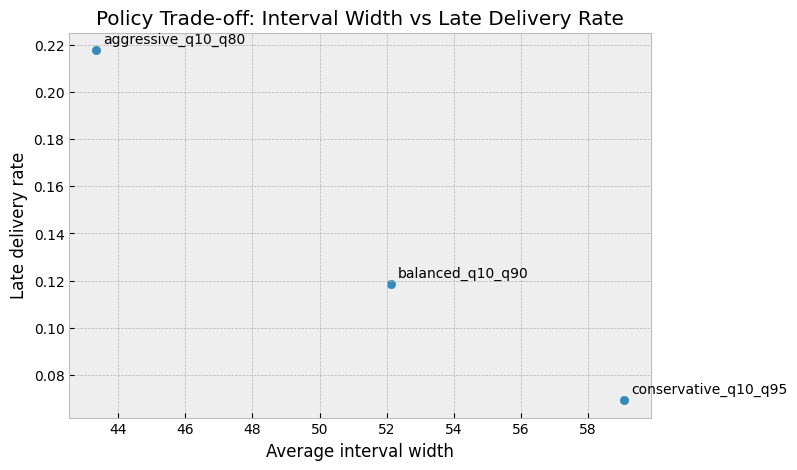

This is the key business plot in the prototype. Narrower intervals improve customer experience, wider intervals improve reliability, and the policy layer determines the operating point between those two goals.

In [22]:
policy_dir = ARTIFACTS_DIR / "policy_analysis"

if not policy_dir.exists():
    render_note(
        "Stage 5 artifacts not found yet; this section is a placeholder for policy trade-off results."
    )
else:
    policy_df = None
    for candidate_path in sorted(policy_dir.glob("*.csv")):
        candidate_df = pd.read_csv(candidate_path)
        policy_col = find_column(candidate_df.columns, ["policy", "policy_name", "name"])
        width_col = find_column(candidate_df.columns, ["avg_interval_width", "average_interval_width", "interval_width"])
        late_col = find_column(candidate_df.columns, ["late_delivery_rate", "late_rate"])
        coverage_col = find_column(candidate_df.columns, ["coverage", "empirical_coverage"])
        if policy_col and width_col and late_col:
            policy_df = candidate_df.rename(
                columns={
                    policy_col: "policy_name",
                    width_col: "avg_interval_width",
                    late_col: "late_delivery_rate",
                    **({coverage_col: "coverage"} if coverage_col else {}),
                }
            )
            break

    if policy_df is None:
        render_note("Policy evaluation artifacts were not found in an expected format yet.")
    else:
        display(policy_df)

        fig, ax = plt.subplots(figsize=(7.5, 5))
        ax.scatter(policy_df["avg_interval_width"], policy_df["late_delivery_rate"])
        for _, row in policy_df.iterrows():
            ax.annotate(
                row["policy_name"],
                (row["avg_interval_width"], row["late_delivery_rate"]),
                xytext=(5, 5),
                textcoords="offset points",
            )
        ax.set_title("Policy Trade-off: Interval Width vs Late Delivery Rate")
        ax.set_xlabel("Average interval width")
        ax.set_ylabel("Late delivery rate")
        plt.show()

        render_note(
            "This is the key business plot in the prototype. Narrower intervals improve customer experience, wider intervals improve reliability, and the policy layer determines the operating point between those two goals."
        )


# Conclusion

- The Stage 2 proxy dataset appears learnable and captures structured variation in delivery lead times.
- The Stage 3 LightGBM point model provides a strong baseline relative to a naive mean predictor.
- Point estimates are useful for benchmarking, but interval prediction is needed for buyer-facing promise generation.
- Policy evaluation is the layer that exposes the business trade-off between promise precision and late-delivery risk.
